# Main result grid (Figure 3)

This notebook produces the paper's central figure: a 2×2 grid of untreated-data
CCM results across the four main-text dyads, pairing temperature targets ERB22 and
ALLEY00 against TSI reconstructions WU18 and VIEIRA11. Each of the four subpanels is
itself a grid over embedding dimension E and time-step τ, one cell per (E, τ)
configuration.

This is the figure where the paper's headline claim, that TSI shows a discernible
influence on temperature in roughly 80% of parameter configurations, becomes visible
at a glance. It also shows the diagonal color gradient, where a longer embedded time
span generally produces a larger Δρ, and the contrast between the two temperature
records: the globally averaged ERB22 is weaker but more consistently significant,
while the single-site ALLEY00 is stronger but less consistently significant.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from cedarkit.viz.panels import ResultsGrid
from cedarkit.viz.grids import GridCell, SummaryGrid
from cedarkit.core.data_var import VarObject
from cedarkit.core.relationship import Relationship
from cedarkit.core.project_config import load_config
from cedarkit.utils.plotting import save_figure

In [2]:
notebook_name = "Fig3__untreated_2x2__final_result_grid"
figures_dir = stem / "figures" / notebook_name
figures_dir.mkdir(exist_ok=True, parents=True)

final_result_grid_path = stem / "hol_temp_tsi_ccm" / "mixed" / "tmp" / "final_result_grid.parquet"
assert final_result_grid_path.is_file(), f"Missing final result grid: {final_result_grid_path}"
print(f"Using {final_result_grid_path}")


Using /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/mixed/tmp/final_result_grid.parquet


## Reading the grid

Rows pair Erb (ERB22, the global-mean record) and Alley (ALLEY00/GISP2, the single
high-latitude site); columns pair Wu (WU18) and Vieira (VIEIRA11), the two TSI
reconstructions. The code labels this "FigS6-style" because it reuses the same
`ResultsGrid` rendering machinery as the fuller SI overview grid (Fig. S6); this
panel is just the untreated-data, four-dyad subset of it.

In [3]:
# Display metadata comes from the small project configurations only;
# no raw timeseries are loaded in this notebook.
var_obj_d = {}
project_name_map = {
    ("Erb", "Wu"): "Erb22daGMST_Wu18TSI",
    ("Erb", "Vieira"): "Erb22daGMST_Vieira11TSI",
    ("Alley", "Wu"): "GISP2Alley00Tanom_Wu18TSI",
    ("Alley", "Vieira"): "GISP2Alley00Tanom_Vieira11TSI",
}
for proj_name in project_name_map.values():
    proj_dir = stem / "hol_temp_tsi_ccm" / proj_name
    proj_config = load_config(proj_dir / "proj_config.yaml")
    for var_type in ["col", "target"]:
        var_id = proj_config.get_dynamic_attr("{var}.var_id", var_type)
        if var_id not in var_obj_d:
            var_obj_d[var_id] = VarObject(proj_config, proj_dir=proj_dir, var_id=var_id)
print("Loaded display metadata for", len(var_obj_d), "variables")


Loaded display metadata for 4 variables


In [4]:
# Build the same deterministic untreated 2x2 layout as the source notebook.
# The only changed input is final_result_grid.parquet instead of object-grid
# OutputCollections and their individual delta_rho_stats files.
row_order = ["Erb", "Alley"]
col_order = ["Wu", "Vieira"]
selection_policy = "object_grid_precomputed"

final_result_grid = pd.read_parquet(final_result_grid_path)
required_columns = {
    "proj_name", "selection_policy", "E", "tau", "maxlibsize_rho",
    "peak_end", "surr_rx_outperforming_frac", "surr_ry_outperforming_frac",
    "var_x", "var_y",
}
missing_columns = required_columns.difference(final_result_grid.columns)
assert not missing_columns, f"Final result grid lacks: {sorted(missing_columns)}"

new_grid_d2 = {}
required_projects = []
for row_idx, row_name in enumerate(row_order):
    for col_idx, col_name in enumerate(col_order):
        proj_name = project_name_map[(row_name, col_name)]
        required_projects.append(proj_name)
        grid_df = final_result_grid.loc[
            (final_result_grid["proj_name"] == proj_name)
            & (final_result_grid["selection_policy"] == selection_policy)
        ].copy()
        if grid_df.empty:
            raise ValueError(f"No exported rows for {proj_name} and {selection_policy}")
        if grid_df.duplicated(["E", "tau"]).any():
            raise ValueError(f"Duplicated E/tau rows in exported data for {proj_name}")

        # This is exactly the source notebook's plotting subset.
        grid_df = grid_df[grid_df.tau < 8].copy()
        source_config = load_config(stem / "hol_temp_tsi_ccm" / proj_name / "proj_config.yaml")
        col_var_id = source_config.get_dynamic_attr("{var}.var_id", "col")
        target_var_id = source_config.get_dynamic_attr("{var}.var_id", "target")
        col_var_obj = var_obj_d[col_var_id]
        target_var_obj = var_obj_d[target_var_id]

        new_cell_obj = GridCell(row_idx, col_idx, output=grid_df)
        row_label = f"{col_var_obj.author}, {col_var_obj.year} ({col_var_obj.var_name.replace('anomaly', '').rstrip()})"
        row_label = row_label.replace("Temp", "Temp, GISP2")
        col_label = f" {target_var_obj.author}, {target_var_obj.year} ({target_var_obj.var_name.replace('anomaly', '').rstrip()})"
        new_cell_obj.row_labels = [f"{row_label}\n\n" + r"$\tau$; snippet timestep (decades)"]
        new_cell_obj.col_labels = [r"$E$; time points/snippet"]
        new_cell_obj.title_labels = [col_label]
        new_cell_obj.ylims = [grid_df["maxlibsize_rho"].quantile(.1), grid_df["maxlibsize_rho"].quantile(.7)]
        new_cell_obj.relationships = Relationship(
            var_x=grid_df["var_x"].dropna().iloc[0],
            var_y=grid_df["var_y"].dropna().iloc[0],
        )
        new_grid_d2[(row_idx, col_idx)] = new_cell_obj

print("Loaded required projects:", required_projects)
print("Grid cells:", sorted(new_grid_d2))


Loaded required projects: ['Erb22daGMST_Wu18TSI', 'Erb22daGMST_Vieira11TSI', 'GISP2Alley00Tanom_Wu18TSI', 'GISP2Alley00Tanom_Vieira11TSI']
Grid cells: [(0, 0), (0, 1), (1, 0), (1, 1)]


In [5]:
# Harmonize y-axis limits across all cells.
min_ylims, max_ylims = [], []
for grid_cell in new_grid_d2.values():
    min_ylims.append(grid_cell.ylims[0])
    max_ylims.append(grid_cell.ylims[1])

ylims = [np.mean(min_ylims), np.mean(max_ylims)]
for key, grid_cell in new_grid_d2.items():
    grid_cell.ylims = ylims
    new_grid_d2[key] = grid_cell

rows = 2
cols = 2
for row in range(rows):
    for col in range(cols):
        if (row, col) not in new_grid_d2:
            new_grid_d2[(row, col)] = None


{'local': PosixPath('/Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/figures/Fig3__untreated_2x2__final_result_grid/Fig3_untreated_results_Grid_2x2_20260825_191912.pdf')}

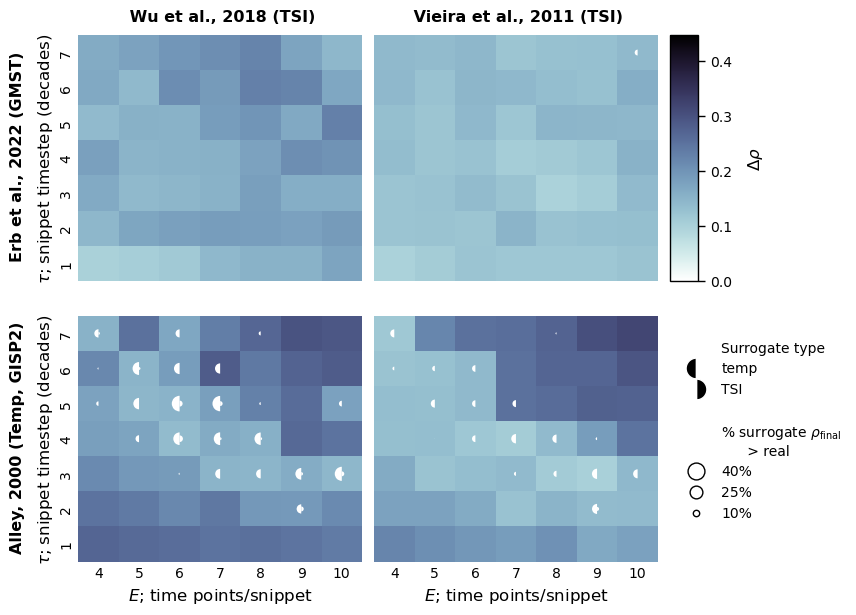

In [6]:
# FigS6-style untreated 2x2 Δρ grid.
rows = 2
cols = 2

width_ratios = [1] * cols + [.1]
gridplot = SummaryGrid(rows, cols + 1, width_ratios=width_ratios)
gridplot.set_font_sizes(context='poster', multiplier=5)
gridplot.make_grid(figsize=(4 * cols, 6.0), wspace=.06, hspace=-.12)

pal = sns.cubehelix_palette(start=.18, rot=-.28, light=1, dark=0, gamma=1, reverse=False, as_cmap=True)
gridplot.palette = pal
gridplot.vlims = min((0, min(ylims))), max((.4, max(ylims)))
gridplot.vlims = max((0, gridplot.vlims[0])), gridplot.vlims[1]
gridplot.cbar_ax = gridplot.get_ax(0, cols)

for (row, col), cell_obj in new_grid_d2.items():
    ax = gridplot.get_ax(row, col)
    ax.set_ylabel(r'$\tau$')

    if cell_obj is None:
        gridplot.set_ax(row, col, ax, entry_type=None)
        continue

    cell_obj.ylims = gridplot.vlims
    res_grid = ResultsGrid(cell_obj.relationships, ax=ax, palette=pal, lag_filter=lambda x: x < 0)
    res_grid.populate_from_cellobj(cell_obj)
    res_grid.plot_heatmap(cell_obj.output.copy())
    res_grid.add_half_moons(cell_obj.output.copy())
    res_grid.mask_nan_cells(cell_obj.output.copy())
    res_grid.tidy_grid()

    gridplot.add_handles_labels(res_grid.line_handles, res_grid.line_labels, kind='line')
    if res_grid.ax is not None:
        res_grid.ax.set_yticklabels([f'{(1 + int(tick))}' for tick in res_grid.ax.get_yticks()])
        gridplot.set_ax(row, col, res_grid.ax, entry_type='heatmap')
        gridplot.marker_d.update(res_grid.marker_d)
        gridplot.sizes = res_grid.sizes
    else:
        gridplot.set_ax(row, col, ax, entry_type='title' if row == 0 else None)

gridplot.cbar_label = r'$\Delta \rho$'
gridplot.create_custom_legend(bbox_to_anchor=(0, .95))
gridplot.tidy_rows(ylim_by='central', supylabel_offset=.06, title_rows=[0])
gridplot.make_colorbar()

save_figure(gridplot.fig, figures_dir, stem="Fig3_untreated_results_Grid_2x2", dry_run=False)


## Interpreting the grid

Cell color encodes Δρ = ρ_final − ρ_initial for the "TSI influences temperature"
relationship at each configuration's optimal lag. A larger Δρ means predictive skill
improved more as the CCM library grew: stronger empirical evidence of a causal link.
The half-moon markers overlaid on each cell show the two surrogate significance
checks: their size tracks the percent of surrogate relationships whose final ρ
matched or beat the real relationship's, with the left half-moon for "TSI influences
temperature (surrogate)" and the right half-moon for "TSI (surrogate) influences
temperature." A configuration only counts as significant if both surrogate
categories fail to catch up with the real relationship.